<a href="https://colab.research.google.com/github/Samarth-27/Celebal-CEI/blob/main/week6_SamarthJain_Jecrc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Denoising Autoencoder

Trains a small autoencoder to clean up noisy MNIST digits. Load MNIST, add noise, train an encoder-decoder to map noise clean, then check how it does on the test set. Built an improved version too after hitting an issue with the first one (more on that below).

In [19]:
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 1. Loading the data

torchvision has MNIST built in, downloads on its own the first run. `ToTensor()` also scales pixels to `[0, 1]`, which matters since the decoder ends in a sigmoid (same range).

In [20]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_data)} | Test samples: {len(test_data)}")
print(f"Image shape: {train_data[0][0].shape}")

Train samples: 60000 | Test samples: 10000
Image shape: torch.Size([1, 28, 28])


## 2. Adding noise

Small function that adds Gaussian noise to a batch and clips it back to `[0, 1]`. `noise_factor` controls how strong it is, used 0.3 for training.

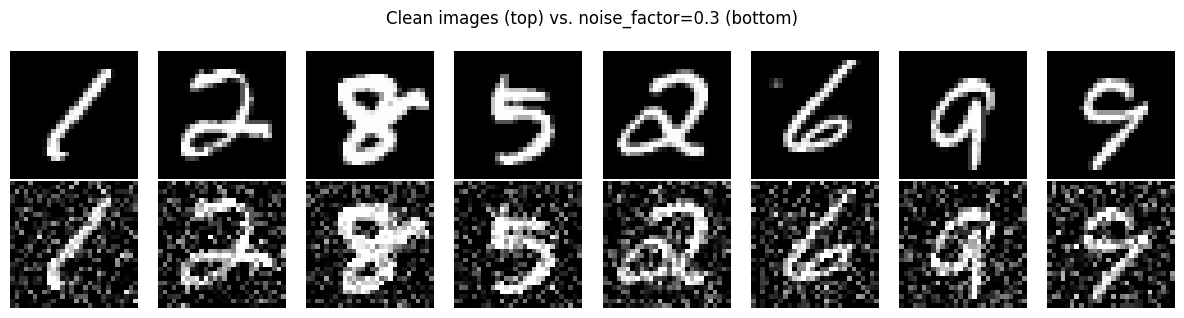

In [21]:
def add_noise(images, noise_factor=0.3):
    noisy = images + noise_factor * torch.randn(*images.shape, device=images.device)
    return torch.clamp(noisy, 0., 1.)


# Quick sanity check: clean vs. noisy
sample_images, _ = next(iter(train_loader))
sample_noisy = add_noise(sample_images)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(sample_images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(sample_noisy[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Clean", fontsize=11)
axes[1, 0].set_ylabel("Noisy", fontsize=11)
fig.suptitle("Clean images (top) vs. noise_factor=0.3 (bottom)")
plt.tight_layout()
plt.show()

## 3. The model

Standard encoder-decoder. Encoder shrinks 28x28 down to 7x7 using conv + maxpool. Decoder reverses that, used upsampling + conv instead of `ConvTranspose2d` to avoid the checkerboard pattern transposed conv is known for.

In [22]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc_conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Decoder
        self.dec_conv1 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.dec_conv2 = nn.Conv2d(32, 1, kernel_size=3, padding=1)

    def forward(self, x):
        # Encode: 28x28 -> 14x14 -> 7x7
        # LeakyReLU(0.1) instead ReLU
        x = self.pool(F.leaky_relu(self.enc_conv1(x), 0.1))
        x = self.pool(F.leaky_relu(self.enc_conv2(x), 0.1))

        # Decode
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = F.leaky_relu(self.dec_conv1(x), 0.1)
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = torch.sigmoid(self.dec_conv2(x))
        return x


model = DenoisingAutoencoder().to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTrainable parameters: {n_params:,}")

DenoisingAutoencoder(
  (enc_conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc_conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dec_conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec_conv2): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

Trainable parameters: 9,873


## 4. Training

MSE loss since I'm comparing pixel values, not class labels. Adam with `lr=1e-4` (explained below why I lowered it from `1e-3`). Noise is regenerated every batch so it doesn't memorize one fixed corruption.

In [23]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

NOISE_FACTOR = 0.3
EPOCHS = 10

train_losses = []
start = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = add_noise(images, NOISE_FACTOR)

        optimizer.zero_grad()
        outputs = model(noisy_images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_data)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | MSE loss: {epoch_loss:.5f} | elapsed: {time.time()-start:.1f}s")

print(f"\nTraining done in {time.time()-start:.1f}s")

Epoch  1/10 | MSE loss: 0.09083 | elapsed: 9.1s
Epoch  2/10 | MSE loss: 0.02188 | elapsed: 18.5s
Epoch  3/10 | MSE loss: 0.01619 | elapsed: 27.7s
Epoch  4/10 | MSE loss: 0.01380 | elapsed: 36.6s
Epoch  5/10 | MSE loss: 0.01240 | elapsed: 45.7s
Epoch  6/10 | MSE loss: 0.01143 | elapsed: 54.9s
Epoch  7/10 | MSE loss: 0.01075 | elapsed: 64.1s
Epoch  8/10 | MSE loss: 0.01020 | elapsed: 73.0s
Epoch  9/10 | MSE loss: 0.00977 | elapsed: 82.0s
Epoch 10/10 | MSE loss: 0.00941 | elapsed: 91.2s

Training done in 91.2s


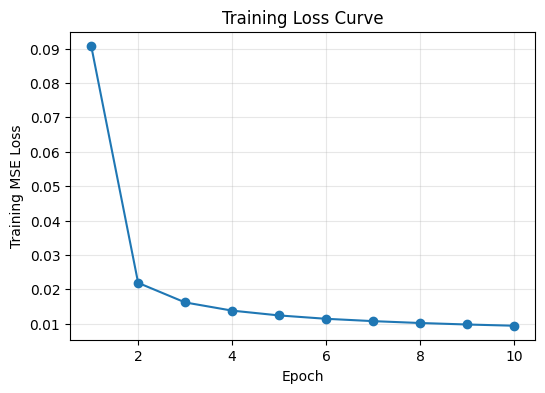

In [24]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss")
plt.title("Training Loss Curve")
plt.grid(alpha=0.3)
plt.show()

**Ran into an issue here:** with plain ReLU and `lr=1e-3`, loss dropped for one epoch then got stuck at the exact same number for the rest of training, basically stopped learning. Turned out to be the dying ReLU problem, a big early update pushes a layer fully negative, and ReLU's gradient is zero there so it never recovers.

Tried `LeakyReLU` alone first, still got stuck (just at a different number), so the final sigmoid was probably saturating too. Combining `LeakyReLU` with a lower learning rate (`1e-4`) fixed it, loss came down smoothly after that.

## 5. Checking the results

Three rows: original, noisy version fed into the model, and what it gave back.

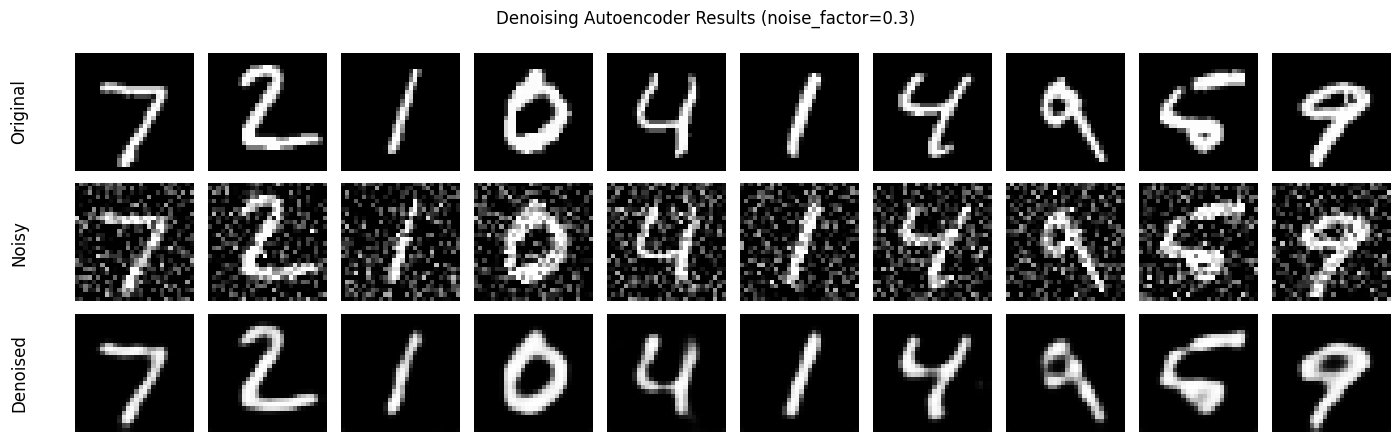

In [25]:
def show_denoising_results(model, loader, noise_factor=0.3, n=10):
    model.eval()
    images, _ = next(iter(loader))
    images = images.to(device)
    noisy_images = add_noise(images, noise_factor)

    with torch.no_grad():
        outputs = model(noisy_images)

    images_np = images.cpu().numpy()
    noisy_np = noisy_images.cpu().numpy()
    outputs_np = outputs.cpu().numpy()

    fig, axes = plt.subplots(3, n, figsize=(1.4 * n, 4.5))
    row_labels = ["Original", "Noisy", "Denoised"]
    for row, data in enumerate([images_np, noisy_np, outputs_np]):
        for col in range(n):
            axes[row, col].imshow(np.squeeze(data[col]), cmap="gray")
            axes[row, col].axis("off")
        axes[row, 0].text(-0.4, 0.5, row_labels[row], transform=axes[row, 0].transAxes,
                           fontsize=12, va="center", ha="right", rotation=90)
    plt.suptitle(f"Denoising Autoencoder Results (noise_factor={noise_factor})")
    plt.tight_layout()
    plt.show()
    return images_np, noisy_np, outputs_np


_ = show_denoising_results(model, test_loader, noise_factor=NOISE_FACTOR, n=10)

In [26]:
# Quantify reconstruction quality on test set
def evaluate(model, loader, noise_factor):
    model.eval()
    mse_total = 0.0
    n_samples = 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            noisy_images = add_noise(images, noise_factor)
            outputs = model(noisy_images)
            mse_total += F.mse_loss(outputs, images, reduction="sum").item()
            n_samples += images.numel()
    mse = mse_total / n_samples
    psnr = 10 * np.log10(1.0 / mse)
    return mse, psnr


test_mse, test_psnr = evaluate(model, test_loader, NOISE_FACTOR)
print(f"Test MSE: {test_mse:.5f} | Test PSNR: {test_psnr:.2f} dB")

Test MSE: 0.00899 | Test PSNR: 20.46 dB


## 6. Bonus: testing other noise levels

Model only trained on `noise_factor=0.3`. Got curious how it'd do on noise it never saw, so ran it (no retraining) at a few different levels and checked MSE/PSNR (higher PSNR = better).

noise_factor=0.1 | MSE: 0.00607 | PSNR: 22.17 dB
noise_factor=0.2 | MSE: 0.00707 | PSNR: 21.51 dB
noise_factor=0.3 | MSE: 0.00899 | PSNR: 20.46 dB
noise_factor=0.5 | MSE: 0.02220 | PSNR: 16.54 dB
noise_factor=0.7 | MSE: 0.05195 | PSNR: 12.84 dB


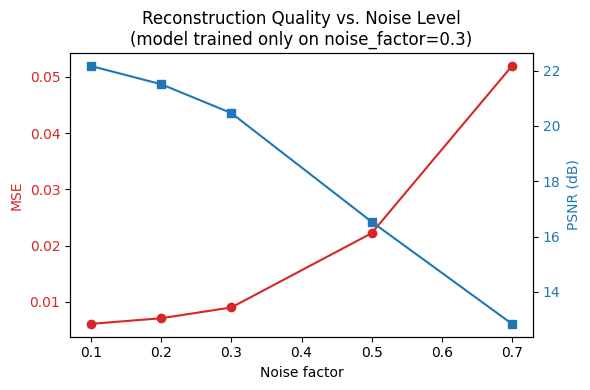

In [27]:
noise_levels = [0.1, 0.2, 0.3, 0.5, 0.7]
results = []
for nf in noise_levels:
    mse, psnr = evaluate(model, test_loader, nf)
    results.append((nf, mse, psnr))
    print(f"noise_factor={nf:.1f} | MSE: {mse:.5f} | PSNR: {psnr:5.2f} dB")

fig, ax1 = plt.subplots(figsize=(6, 4))
nf_vals = [r[0] for r in results]
mse_vals = [r[1] for r in results]
psnr_vals = [r[2] for r in results]

ax1.plot(nf_vals, mse_vals, marker="o", color="tab:red", label="MSE")
ax1.set_xlabel("Noise factor")
ax1.set_ylabel("MSE", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(nf_vals, psnr_vals, marker="s", color="tab:blue", label="PSNR (dB)")
ax2.set_ylabel("PSNR (dB)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("Reconstruction Quality vs. Noise Level\n(model trained only on noise_factor=0.3)")
fig.tight_layout()
plt.show()

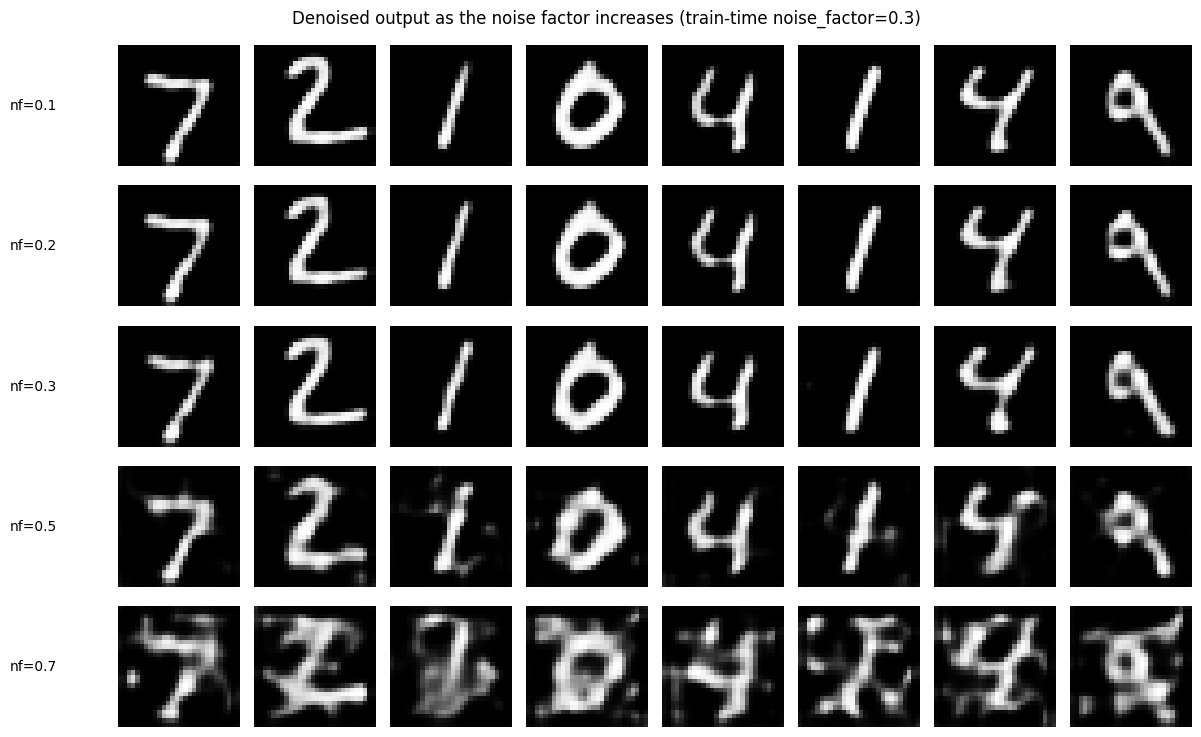

In [28]:
# Visual comparison at the noise levels above
fig, axes = plt.subplots(len(noise_levels), 8, figsize=(12, 1.5 * len(noise_levels)))
images, _ = next(iter(test_loader))
images = images.to(device)

model.eval()
for row, nf in enumerate(noise_levels):
    noisy_images = add_noise(images, nf)
    with torch.no_grad():
        outputs = model(noisy_images)
    for col in range(8):
        axes[row, col].imshow(outputs[col].cpu().squeeze(), cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].text(-0.5, 0.5, f"nf={nf}", transform=axes[row, 0].transAxes,
                       fontsize=10, va="center", ha="right")
plt.suptitle("Denoised output as the noise factor increases (train-time noise_factor=0.3)")
plt.tight_layout()
plt.show()

## What I noticed

Most of the improvement happens in the first couple epochs, after that it's just small refinements. At 0.3 (what it trained on) the digits come out pretty close to the original, though it feels less like "removing noise" and more like the model pulling everything toward the nearest digit shape it knows.

Performance falls off unevenly across noise levels, basically flat below 0.3, then drops hard past 0.5 once the noise starts hiding the digit itself instead of just sitting on top of it. Edges are a bit blurry too, probably the price of squeezing everything through that 7x7 bottleneck.

Only trained on one noise level though. Tried fixing that next.

## 7. Trying to improve it

In [29]:
class ImprovedDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc_conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.enc_conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2)

        # Decoder
        self.dec_conv1 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.dec_conv2 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)
        self.out_conv = nn.Conv2d(32, 1, kernel_size=3, padding=1)

    def forward(self, x):
        e1 = F.relu(self.bn1(self.enc_conv1(x)))
        p1 = self.pool(e1)
        e2 = F.relu(self.bn2(self.enc_conv2(p1)))
        bottleneck = self.pool(e2)

        d1 = F.interpolate(bottleneck, scale_factor=2, mode="nearest")
        d1 = F.relu(self.bn3(self.dec_conv1(d1)))
        d1 = F.interpolate(d1, scale_factor=2, mode="nearest")
        d1 = torch.cat([d1, e1], dim=1)
        d2 = F.relu(self.bn4(self.dec_conv2(d1)))
        out = torch.sigmoid(self.out_conv(d2))
        return out


improved_model = ImprovedDenoisingAutoencoder().to(device)
print(improved_model)
n_params = sum(p.numel() for p in improved_model.parameters())
print(f"\nTrainable parameters: {n_params:,} (baseline had {sum(p.numel() for p in model.parameters()):,})")

ImprovedDenoisingAutoencoder(
  (enc_conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dec_conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dec_conv2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (out_conv): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

Trainable parameters: 28,561 (baseline had 9,873)


Tried fixing two things: the blur, and only ever training on one noise level.

Added a skip connection (saving the first encoder layer's output and feeding it back into the decoder later) so it's not rebuilding everything from the 7x7 bottleneck alone. Also randomized the noise factor per batch, 0.1 to 0.6 instead of fixed at 0.3, and threw in BatchNorm since the extra depth made me a bit nervous about stability.

Kept the loss, optimizer, and epochs the same as before so any difference actually comes from these changes, not extra training.

In [30]:
def add_random_noise(images, low=0.1, high=0.6):
    """Corrupt a batch at a noise factor sampled uniformly from [low, high],
    instead of a single fixed noise factor."""
    noise_factor = np.random.uniform(low, high)
    return add_noise(images, noise_factor)

In [31]:
improved_criterion = nn.MSELoss()
improved_optimizer = torch.optim.Adam(improved_model.parameters(), lr=1e-3)

improved_train_losses = []
start = time.time()

for epoch in range(EPOCHS):
    improved_model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = add_random_noise(images)

        improved_optimizer.zero_grad()
        outputs = improved_model(noisy_images)
        loss = improved_criterion(outputs, images)
        loss.backward()
        improved_optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_data)
    improved_train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | MSE loss: {epoch_loss:.5f} | elapsed: {time.time()-start:.1f}s")

print(f"\nTraining done in {time.time()-start:.1f}s")

Epoch  1/10 | MSE loss: 0.01231 | elapsed: 10.8s
Epoch  2/10 | MSE loss: 0.00728 | elapsed: 21.3s
Epoch  3/10 | MSE loss: 0.00629 | elapsed: 31.7s
Epoch  4/10 | MSE loss: 0.00693 | elapsed: 42.5s
Epoch  5/10 | MSE loss: 0.00658 | elapsed: 53.2s
Epoch  6/10 | MSE loss: 0.00632 | elapsed: 63.9s
Epoch  7/10 | MSE loss: 0.00637 | elapsed: 74.7s
Epoch  8/10 | MSE loss: 0.00626 | elapsed: 85.4s
Epoch  9/10 | MSE loss: 0.00647 | elapsed: 96.1s
Epoch 10/10 | MSE loss: 0.00647 | elapsed: 106.6s

Training done in 106.6s


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", label="Baseline (fixed noise=0.3)")
plt.plot(range(1, EPOCHS + 1), improved_train_losses, marker="s", label="Improved (random noise, skip connection)")
plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss")
plt.title("Training Loss: Baseline vs. Improved Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Comparing the two models

First model only saw `noise_factor=0.3`, so compared both at `0.6` to see if the gap shows up, plus the same noise-level test from before but for both models.

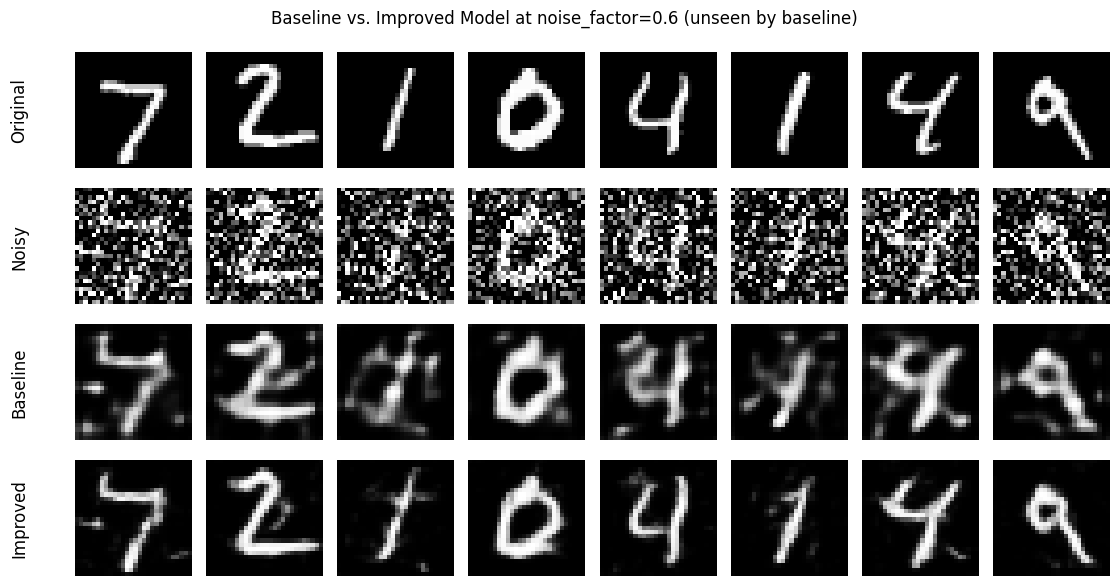

In [33]:
def compare_models_visually(baseline, improved, loader, noise_factor=0.6, n=8):
    baseline.eval()
    improved.eval()
    images, _ = next(iter(loader))
    images = images.to(device)
    noisy_images = add_noise(images, noise_factor)

    with torch.no_grad():
        baseline_out = baseline(noisy_images)
        improved_out = improved(noisy_images)

    rows = [images.cpu().numpy(), noisy_images.cpu().numpy(),
            baseline_out.cpu().numpy(), improved_out.cpu().numpy()]
    row_labels = ["Original", "Noisy", "Baseline", "Improved"]

    fig, axes = plt.subplots(4, n, figsize=(1.4 * n, 6))
    for row, data in enumerate(rows):
        for col in range(n):
            axes[row, col].imshow(np.squeeze(data[col]), cmap="gray")
            axes[row, col].axis("off")
        axes[row, 0].text(-0.4, 0.5, row_labels[row], transform=axes[row, 0].transAxes,
                           fontsize=12, va="center", ha="right", rotation=90)
    plt.suptitle(f"Baseline vs. Improved Model at noise_factor={noise_factor} (unseen by baseline)")
    plt.tight_layout()
    plt.show()


compare_models_visually(model, improved_model, test_loader, noise_factor=0.6, n=8)

noise_factor |  Baseline MSE |  Baseline PSNR |  Improved MSE |  Improved PSNR
         0.1 |       0.00607 |          22.17 |       0.00234 |          26.31
         0.2 |       0.00705 |          21.52 |       0.00310 |          25.09
         0.3 |       0.00898 |          20.47 |       0.00449 |          23.48
         0.5 |       0.02224 |          16.53 |       0.01131 |          19.47
         0.7 |       0.05209 |          12.83 |       0.03019 |          15.20


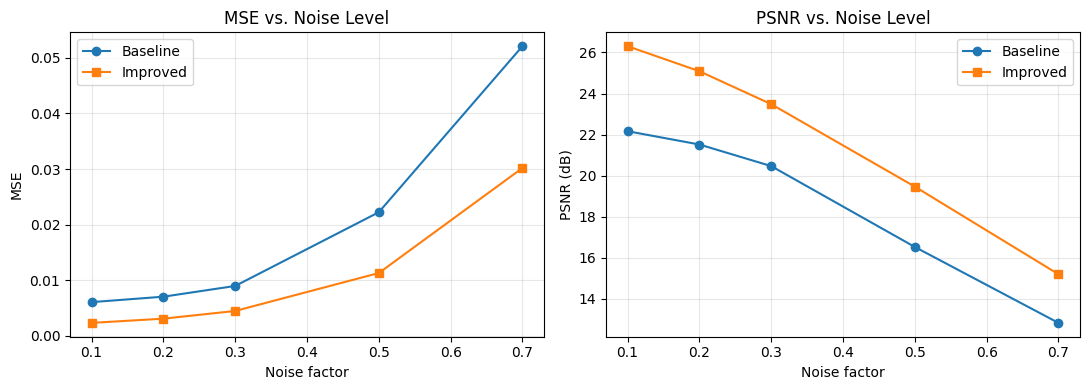

In [18]:
baseline_results = [(nf, *evaluate(model, test_loader, nf)) for nf in noise_levels]
improved_results = [(nf, *evaluate(improved_model, test_loader, nf)) for nf in noise_levels]

print(f"{'noise_factor':>12} | {'Baseline MSE':>13} | {'Baseline PSNR':>14} | {'Improved MSE':>13} | {'Improved PSNR':>14}")
for (nf, b_mse, b_psnr), (_, i_mse, i_psnr) in zip(baseline_results, improved_results):
    print(f"{nf:>12.1f} | {b_mse:>13.5f} | {b_psnr:>14.2f} | {i_mse:>13.5f} | {i_psnr:>14.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(noise_levels, [r[1] for r in baseline_results], marker="o", label="Baseline")
ax1.plot(noise_levels, [r[1] for r in improved_results], marker="s", label="Improved")
ax1.set_xlabel("Noise factor")
ax1.set_ylabel("MSE")
ax1.set_title("MSE vs. Noise Level")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(noise_levels, [r[2] for r in baseline_results], marker="o", label="Baseline")
ax2.plot(noise_levels, [r[2] for r in improved_results], marker="s", label="Improved")
ax2.set_xlabel("Noise factor")
ax2.set_ylabel("PSNR (dB)")
ax2.set_title("PSNR vs. Noise Level")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Final thoughts

Skip connection helped with the blur, more noticeable at higher noise.

Improved model won at every noise level tested, wasn't expecting it to be this consistent.

One thing that surprised me - thought the gap would be biggest at 0.6/0.7 since baseline never trained there, but it's the opposite, biggest at low noise instead. Maybe the skip connection's features get too noisy themselves at high noise to help much. Not fully sure though.

Also changed the architecture and noise schedule together, so can't really say which one mattered more without testing them separately.